In [1]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date, timedelta
from matplotlib.dates import MO, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter, MO
from IPython.display import HTML
from matplotlib.ticker import PercentFormatter, StrMethodFormatter

plots_filepath = 'plots/august-25/'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo

def format_date_with_suffix(date_obj):
    # 1) turn str or datetime/date into a pd.Timestamp
    ts = pd.to_datetime(date_obj)

    # 2) get the day and compute the ordinal suffix
    day = ts.day
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')

    # 3) build the final string
    #    Month name: ts.strftime('%B')
    #    Day + suffix: f'{day}{suffix}'
    #    Year: ts.year
    return f"{ts.strftime('%B')} {day}{suffix}, {ts.year}"


today = datetime.today()
date = format_date_with_suffix(today)

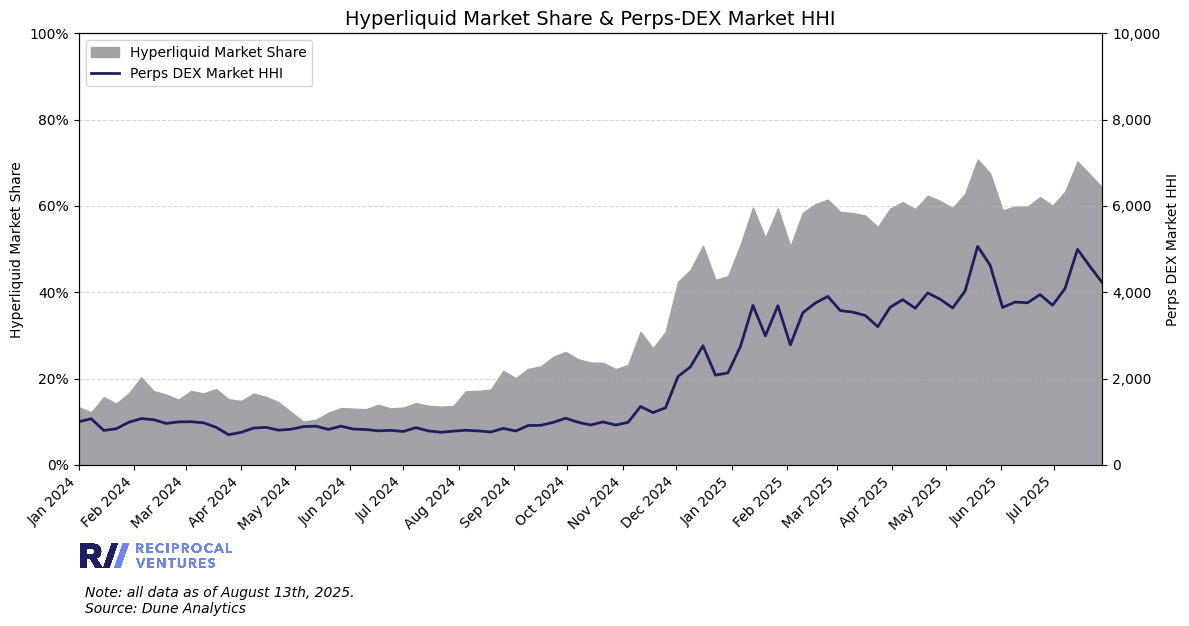

In [2]:
def plot_perpetual_volumes_from_json(json_path):
    # Load & parse the weekly JSON
    with open(json_path, 'r') as f:
        js = json.load(f)
    rows = js['result']['rows']
    df_w = pd.DataFrame(rows)
    # parse week → datetime
    df_w['date'] = pd.to_datetime(df_w['week'], utc=True)
    
    # Pivot so each row is a week, each column a product
    weekly = (
        df_w
        .pivot_table(
            index='date',
            columns='product_name',
            values='volume',
            aggfunc='sum'
        )
        .fillna(0)
    )
    
    # Compute total weekly volume & drop any weeks with zero total
    weekly['total_volume'] = weekly.sum(axis=1)
    weekly = weekly[weekly['total_volume'] > 0]

    # Market share (Hyperliquid) & HHI
    weekly['market_share'] = weekly['Hyperliquid Perps'] / weekly['total_volume'] * 100
    shares = weekly.drop(columns=['total_volume','market_share']).div(weekly['total_volume'], axis=0) * 100
    weekly['hhi'] = (shares ** 2).sum(axis=1)
    plot_df = weekly

    # Filter by index
    plot_df = plot_df[plot_df.index >= pd.to_datetime('2024-01-01', utc=True)]

    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Area: Hyperliquid 7-week avg share
    ax1.fill_between(
        plot_df.index, plot_df['market_share'],
        color="#a4a2a8", alpha=1,
        label="Hyperliquid Market Share"
    )
    ax1.set_ylabel("Hyperliquid Market Share")
    ax1.set_ylim(0, 100)
    ax1.yaxis.set_major_formatter(PercentFormatter())

    # X-axis from first → last
    ax1.set_xlim(plot_df.index[0], plot_df.index[-1])
    ax1.margins(x=0)
    fig.subplots_adjust(left=0.07)

    # Monthly tick locator & formatter
    ax1.xaxis.set_major_locator(MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

    # Line: Perps-DEX HHI
    ax2 = ax1.twinx()
    ax2.plot(
        plot_df.index, plot_df['hhi'],
        color="#1f1f60", linewidth=2,
        label="Perps DEX Market HHI"
    )
    ax2.set_ylabel("Perps DEX Market HHI")
    ax2.set_ylim(0, 10_000)
    ax2.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    # Title, grid & legend
    ax1.set_title(
        "Hyperliquid Market Share & Perps-DEX Market HHI",
        fontsize=14
    )
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")

    # Add logo & footer text
    add_logo(ax1, position=(0.075, -0.21))
    latest = plot_df.index[-1].strftime("%b %d, %Y")
    plt.figtext(
        0.075, -0.03,
        f"Note: all data as of {date}.\nSource: Dune Analytics",
        ha="left", fontsize=10, style="italic"
    )

    # tighten & save
    plt.tight_layout()
    os.makedirs("plots", exist_ok=True)
    plt.savefig(
        f"{plots_filepath}/hyperliquid_marketshare_hhi_7w.png",
        dpi=300, bbox_inches="tight"
    )
    plt.show()

# Usage
plot_perpetual_volumes_from_json("raw-data/dune-raw-data/dune_weekly-perps-dex-volumes.json")


In [3]:
# Function for plotting revenue or fees / mcap or fdv charts for a set of assets

def annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title):
    df_master = None
    # Load revenue and FDV data
    for asset_slug, asset_name in assets.items():
        rev_path = f"raw-data/defillama-raw-data/daily{metric}_data/{asset_slug}_{metric}.json"
        with open(rev_path) as rev_f:
            rev_data = json.load(rev_f)
    
        rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{metric}"])
        rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
        rev_df[f"{asset_slug}-annualized-{metric}"] = rev_df[f"{asset_slug}-{metric}"] * 365
        rev_df = rev_df[["date", f"{asset_slug}-annualized-{metric}"]]

        # Load TVL data
        tvl_path = f"raw-data/defillama-raw-data/tvl_data/{asset_slug}_tvl.json"
        with open(tvl_path) as tvl_f:
            tvl_data = json.load(tvl_f)

        tvl_df = pd.DataFrame(
            tvl_data['tvl'],
            columns=['date', 'totalLiquidityUSD']
        )
        tvl_df.rename(columns={
            'date': 'timestamp',
            'totalLiquidityUSD': f'{asset_slug}-tvl'
        }, inplace=True)
        tvl_df['date'] = pd.to_datetime(tvl_df['timestamp'], unit='s')
        tvl_df = tvl_df[['date', f'{asset_slug}-tvl']]
        
        # Merge datasets for a given asset
        interim_df = pd.merge(rev_df, tvl_df, on="date", how="outer")

        # Fill blanks
        interim_df = interim_df.ffill()
        
        # Calculate multiple
        interim_df[f'{asset_slug}-annualized-{metric}-to-tvl-multiple'] = interim_df[f'{asset_slug}-annualized-{metric}'] / interim_df[f'{asset_slug}-tvl']
        interim_df[f'{asset_slug}-annualized-{metric}-to-tvl-multiple-7d'] = interim_df[f'{asset_slug}-annualized-{metric}-to-tvl-multiple'].rolling(window=7, min_periods=1).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    fdv_cols = [
        f"{asset_slug}-tvl"
        for asset_slug, asset_name in assets.items()
    ]
    mult_cols = [
        f'{asset_slug}-annualized-{metric}-to-tvl-multiple'
        for asset_slug, asset_name in assets.items()
    ]  
        
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master['tvl_weighted_avg_multiple'] = sum(weighted_terms)

    df_master['tvl_weighted_avg_multiple-7d'] = df_master['tvl_weighted_avg_multiple'].rolling(window=7, min_periods=1).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-annualized-{metric}-to-tvl-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: Return on Assets')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:,.0f}%'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.3, f"Note: all data as of {date}.\nROA calcualted as annualized fees / TVL. All figures are 7-day rolling averages.\nSource: DefiLlama",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}select-{category_title}-roas.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    # Calculate statistical percentiles for multiple
    median_cohort = round(df_master[f'tvl_weighted_avg_multiple'].median(), 2) * 100
    latest_cohort_multiple = round(df_master[f'tvl_weighted_avg_multiple'].dropna().iloc[-1],2) * 100
    mean_cohort = round(df_master[f'tvl_weighted_avg_multiple'].mean(), 2) * 100
    percentile_80_cohort = round(df_master[f'tvl_weighted_avg_multiple'].quantile(0.80),2) * 100
    percentile_20_cohort = round(df_master[f'tvl_weighted_avg_multiple'].quantile(0.20),2) * 100
    stdev_cohort = round(df_master[f'tvl_weighted_avg_multiple'].std(),2) * 100

    stats_cohort = {
        "median_multiple": median_cohort,
        'latest_multiple': latest_cohort_multiple,
        'mean_multiple': mean_cohort,
        "80th_percentile_multiple": percentile_80_cohort,
        "20th_percentile_multiple": percentile_20_cohort,
        'stdev_multiple': stdev_cohort
    }

    # Print results in human-readable format
    print()
    print(f"{category_title} ROA Statistics:")
    print(f"Median ROA: {median_cohort:,.0f}%")
    print(f"Latest ROA: {latest_cohort_multiple:,.0f}%")
    print(f"Mean ROA: {mean_cohort:,.0f}%")
    print(f"80th Percentile ROA: {percentile_80_cohort:,.0f}%")
    print(f"20th Percentile ROA: {percentile_20_cohort:,.0f}%")
    print(f'Standard Deviation: {stdev_cohort:,.0f}%')
    print()

    return stats_cohort

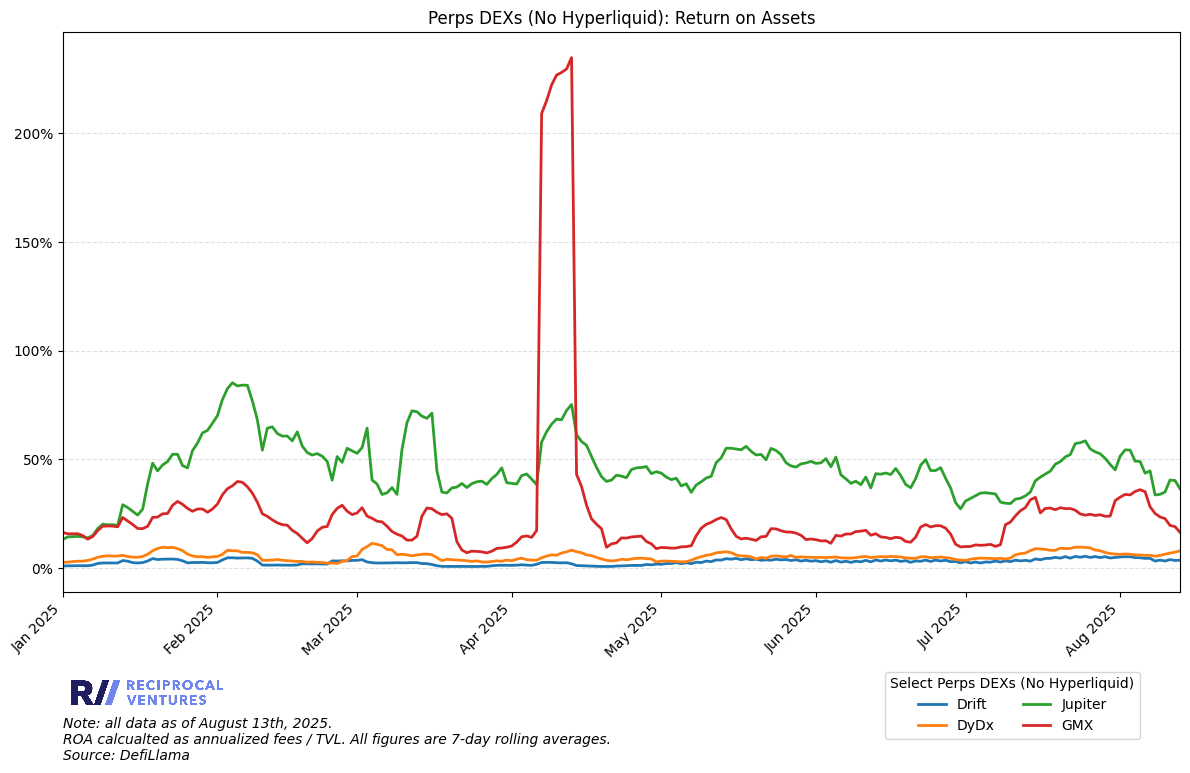


Perps DEXs (No Hyperliquid) ROA Statistics:
Median ROA: 27%
Latest ROA: 1%
Mean ROA: 31%
80th Percentile ROA: 38%
20th Percentile ROA: 18%
Standard Deviation: 22%



In [4]:
# Call the function
perps_dexs = {
          'drift': 'Drift',
          'dydx': 'DyDx',
          'jupiter': 'Jupiter',
          'gmx': 'GMX'
             }

# 'metric' should be 'Fees' or 'Revenue'
start_date = '2025-01-01'
assets = perps_dexs
metric = 'Fees'
category_title = 'Perps DEXs (No Hyperliquid)'

perps_dexs_no_hyperliquid_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

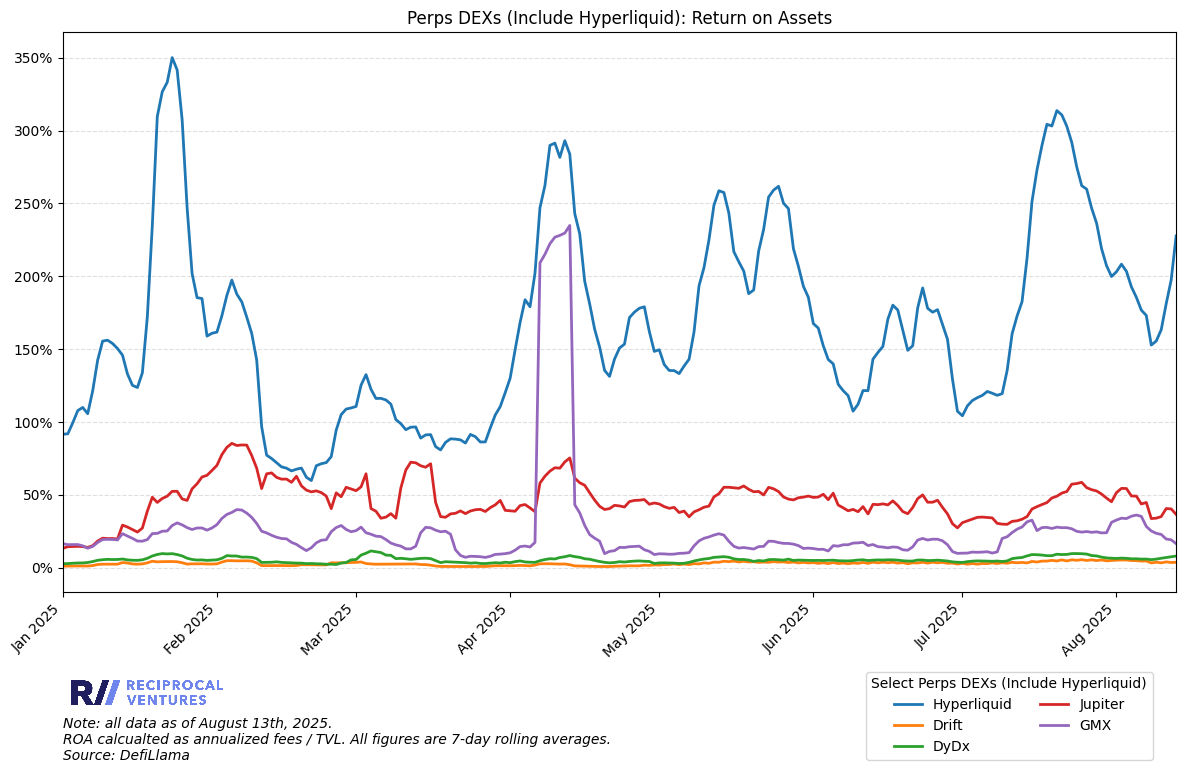


Perps DEXs (Include Hyperliquid) ROA Statistics:
Median ROA: 39%
Latest ROA: 37%
Mean ROA: 44%
80th Percentile ROA: 56%
20th Percentile ROA: 28%
Standard Deviation: 24%



In [5]:
# Call the function
perps_dexs = {'hyperliquid': 'Hyperliquid',
          'drift': 'Drift',
          'dydx': 'DyDx',
          'jupiter': 'Jupiter',
          'gmx': 'GMX'
             }

# 'metric' should be 'Fees' or 'Revenue'
start_date = '2025-01-01'
assets = perps_dexs
metric = 'Fees'
category_title = 'Perps DEXs (Include Hyperliquid)'

perps_dexs_incl_hyperliquid_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

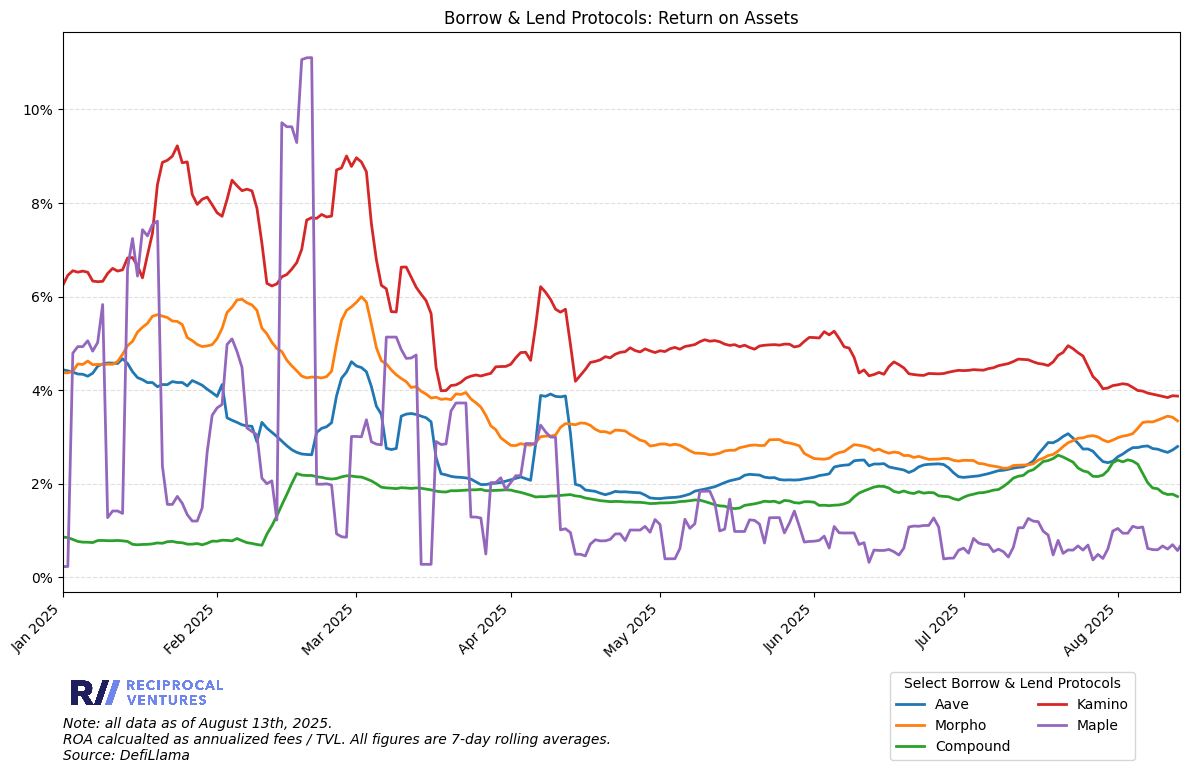


Borrow & Lend Protocols ROA Statistics:
Median ROA: 2%
Latest ROA: 3%
Mean ROA: 3%
80th Percentile ROA: 4%
20th Percentile ROA: 2%
Standard Deviation: 1%



In [6]:
# Call the function
borrow_lend_protocols = {'aave': 'Aave',
                         'morpho': 'Morpho',
                         'compound': 'Compound',
                         'kamino': 'Kamino',
                         'maple-finance': 'Maple',
                        }

# 'metric' should be 'Fees' or 'Revenue'
assets = borrow_lend_protocols
category_title = 'Borrow & Lend Protocols'

borrow_lend_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

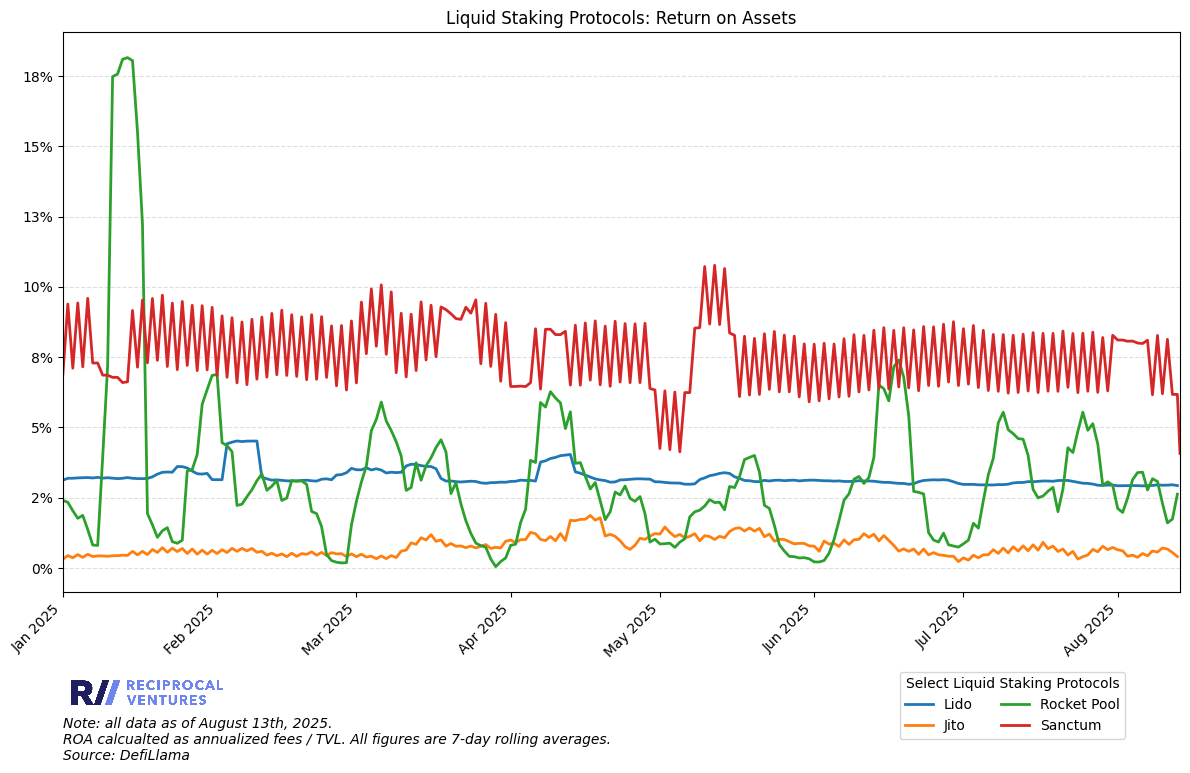


Liquid Staking Protocols ROA Statistics:
Median ROA: 3%
Latest ROA: 3%
Mean ROA: 3%
80th Percentile ROA: 4%
20th Percentile ROA: 3%
Standard Deviation: 1%



In [7]:
# Call the function
liquid_staking = {'lido': 'Lido',
                        'jito-liquid-staking': 'Jito',
                        'rocket-pool': 'Rocket Pool',
                        'sanctum-validator-lsts': 'Sanctum'
                       }

# 'metric' should be 'Fees' or 'Revenue'
assets = liquid_staking
category_title = 'Liquid Staking Protocols'

liquid_staking_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

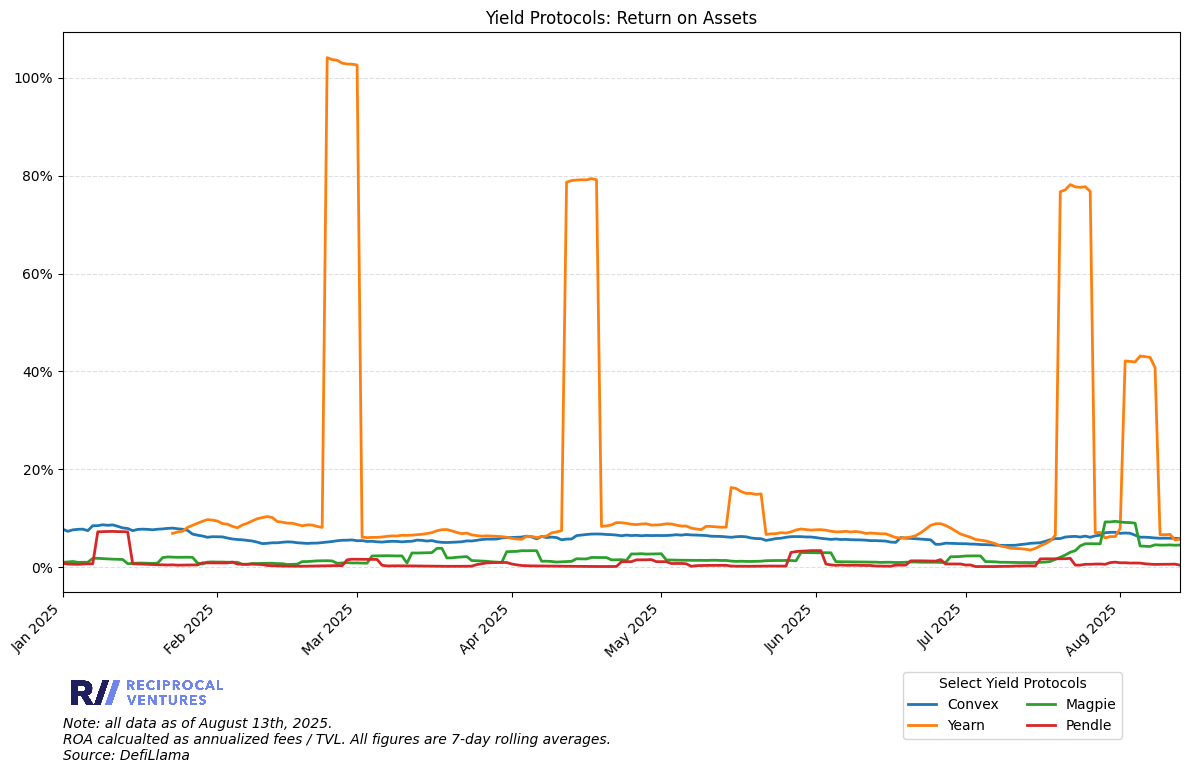


Yield Protocols ROA Statistics:
Median ROA: 2%
Latest ROA: 1%
Mean ROA: 2%
80th Percentile ROA: 2%
20th Percentile ROA: 1%
Standard Deviation: 3%



In [8]:
# Call the function
yield_protocols= {'convex-finance': 'Convex',
          'yearn-finance': 'Yearn',
          'magpie-ecosystem': 'Magpie',
          'pendle': 'Pendle'
             }

# 'metric' should be 'Fees' or 'Revenue'
assets = yield_protocols
category_title = 'Yield Protocols'

yield_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

In [9]:
start_date = format_date_with_suffix(start_date)

combined_stats = pd.DataFrame({
    'Perps DEXs (Incl. Hyperliquid)':                perps_dexs_incl_hyperliquid_stats,
    'Perps DEXs (No Hyperliquid)': perps_dexs_no_hyperliquid_stats,
    'Borrow / Lend': borrow_lend_stats,
    'Liquid Staking': liquid_staking_stats,
    'Yield Aggregator': yield_stats

})

combined_stats.index = [
    'Median',
    'Most Recent',
    'Mean',
    '80th Percentile',
    '20th Percentile',
    'Standard Deviation'
]

# Re-order and keep only the fields I want to display
desired_order = ['Median', '80th Percentile', '20th Percentile', 'Standard Deviation']
filtered_stats = combined_stats.reindex(desired_order)

styled = (
    filtered_stats
      .style
      .set_caption("Annualized Fees / TVL by Protocol Type")
      .set_table_styles([
          {"selector": "caption",
           "props": [
             ("font-weight", "bold"),
             ("caption-side", "top"),
             ("text-decoration", "underline")
           ]},
          {"selector": "thead th", "props": [("font-weight", "normal")]},
          {"selector": "tbody th", "props": [("font-weight", "normal")]}
      ], overwrite=False)
      .format(lambda v: f"{v:,.0f}%" if pd.notnull(v) else "")
)

display(styled)


print(f"""
Notes:
 • All data from {start_date} to {date}.
 • Perp DEXs includes: Drift, dYdX, GMX, Hyperliquid, and Jupiter.
 • Borrow / Lend Protocols includes: Aave, Compound, Kamino, Maple, and Morpho.
 • Liquid Staking Protocols includes: Lido, Jito, Rocket Pool, and Sanctum.
 • Yield Aggregator Protocols includes: Convex, Magpie, Pendle, and Yearn.
 • All figures are TVL-weighted.
 
 Sources: DefiLlama.
""")

,Perps DEXs (Incl. Hyperliquid),Perps DEXs (No Hyperliquid),Borrow / Lend,Liquid Staking,Yield Aggregator
Median,39%,27%,2%,3%,2%
80th Percentile,56%,38%,4%,4%,2%
20th Percentile,28%,18%,2%,3%,1%
Standard Deviation,24%,22%,1%,1%,3%



Notes:
 • All data from January 1st, 2025 to August 13th, 2025.
 • Perp DEXs includes: Drift, dYdX, GMX, Hyperliquid, and Jupiter.
 • Borrow / Lend Protocols includes: Aave, Compound, Kamino, Maple, and Morpho.
 • Liquid Staking Protocols includes: Lido, Jito, Rocket Pool, and Sanctum.
 • Yield Aggregator Protocols includes: Convex, Magpie, Pendle, and Yearn.
 • All figures are TVL-weighted.
 
 Sources: DefiLlama.



In [10]:
def plot_tvl_single_asset(asset_slug, asset_name, start_date):
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    # Load TVL data
    tvl_path = f"raw-data/defillama-raw-data/tvl_data/{asset_slug}_tvl.json"
    with open(tvl_path) as tvl_f:
        tvl_data = json.load(tvl_f)

    tvl_df = pd.DataFrame(
        tvl_data['tvl'],
        columns=['date', 'totalLiquidityUSD']
    )
    tvl_df.rename(columns={
        'date': 'timestamp',
        'totalLiquidityUSD': f'{asset_slug}-tvl'
    }, inplace=True)
    tvl_df['date'] = pd.to_datetime(tvl_df['timestamp'], unit='s')
    tvl_df = tvl_df[['date', f'{asset_slug}-tvl']]

    tvl_df = tvl_df.ffill()

    # Calculate trailing 7-day average
    tvl_df[f"{asset_slug}-tvl-7d"] = tvl_df[f"{asset_slug}-tvl"].rolling(window=7, min_periods=1).mean()

    df_master = tvl_df

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    ax.stackplot(
        df_master['date'], 
        df_master[f'{asset_slug}-tvl-7d'], 
        labels=asset_name, 
        colors = asset_colors
    )
    
    # Setting labels and title
    ax.set_title(f'{asset_name} TVL')
    ax.margins(x=0)
    delta = (today - df_master['date'].iloc[0]).days
    if delta < 60:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    else:
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:,.0f}m'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}{asset_slug}-tvl.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

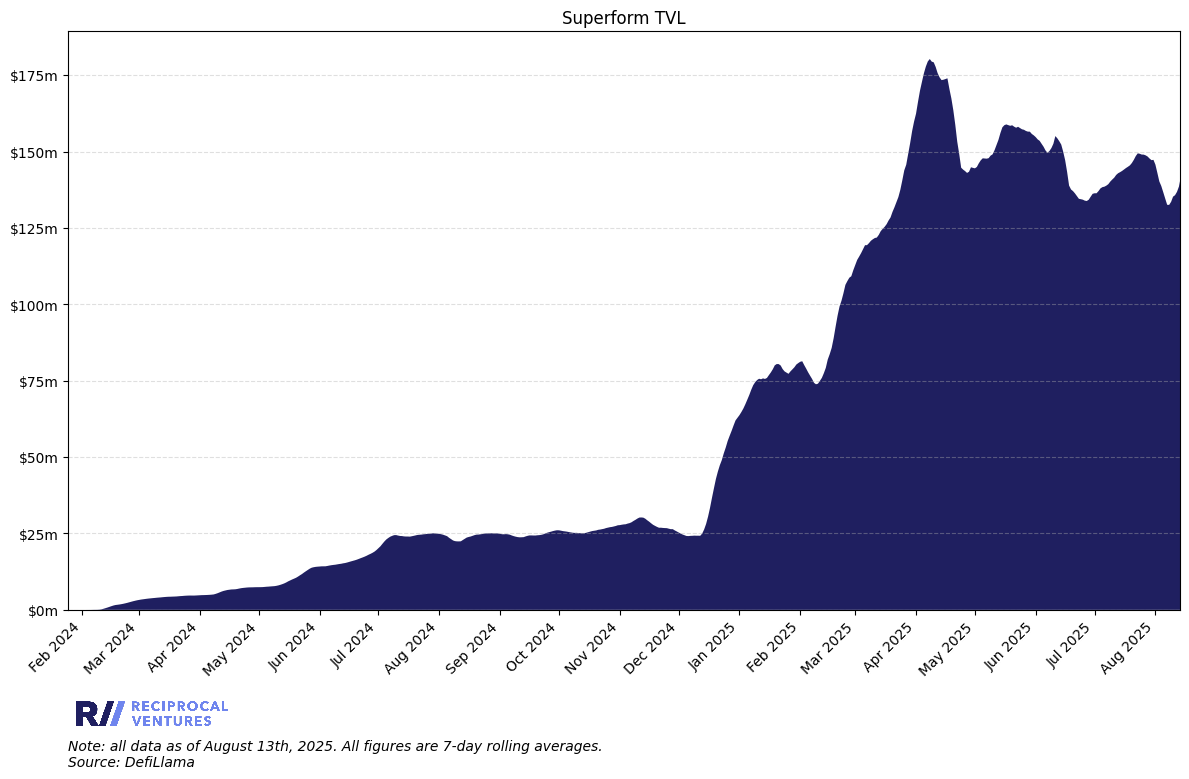

In [11]:
asset_slug = 'superform' 
asset_name = 'Superform'
start_date = '2024-01-01'

plot_tvl_single_asset(asset_slug, asset_name, start_date)

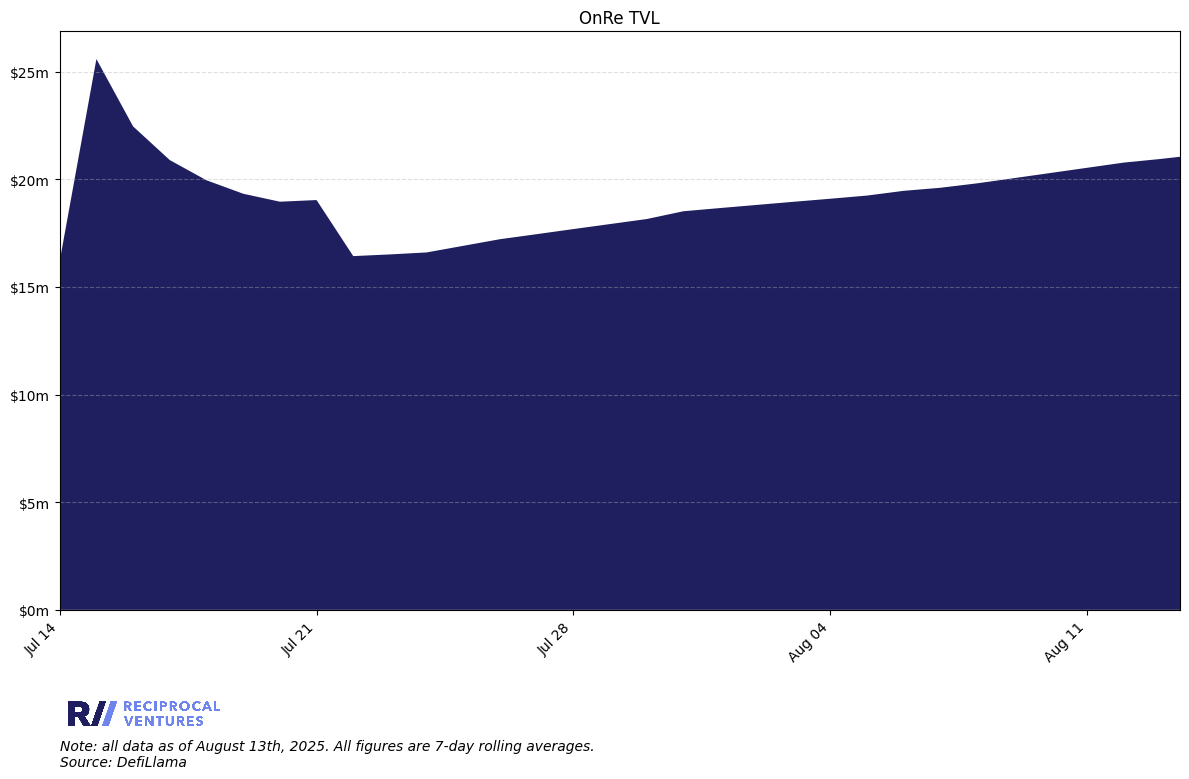

In [12]:
asset_slug = 'onre' 
asset_name = 'OnRe'
start_date = '2025-06-01'

plot_tvl_single_asset(asset_slug, asset_name, start_date)

In [13]:
asset_colors = ['#1f1f60',
                '#313EA5',
                '#7C9ACC',
                '#ADD8E6',
                '#333333',
                '#494949',
                '#5F5F5F',
                '#757575',
                '#8A8A8A',
                '#A0A0A0',
                '#B6B6B6',
                '#CCCCCC'
               ]

def hyperliquid_daily_voume_by_asset(start_date, n_assets, n_col):
    dfs = []
    # Convert daily volume json to dataframe
    path = f'raw-data/dune-raw-data/dune_hyperliquid-daily-volume-by-coin.json'
    with open(path, 'r') as f:
        data = json.load(f)
    entries = data['result']['rows']
    
    # Set up dataframe
    df = pd.DataFrame.from_records(entries)
    df['date'] = pd.to_datetime(df['day'], format='%Y-%m-%d %H:%M:%S.%f UTC').dt.normalize()
    df_wide = df.pivot(index='date', columns='coin', values='daily_volume_usd').fillna(0).sort_index()

    # Slice the date window
    start     = pd.Timestamp(start_date)
    end_date  = (datetime.now() - timedelta(days=0)).date()
    df_plot   = df_wide.loc[start:end_date]
    if df_plot.empty:
        print(f"No data found between {start.date()} and {end_date}.")
        return

    # Pick n assets and roll up the rest
    totals       = df_plot.sum(axis=0)
    top_assets   = totals.nlargest(n_assets).index.tolist()
    other_assets = [c for c in df_plot.columns if c not in top_assets]

    df_top = df_plot[top_assets].copy()
    df_top['Other'] = df_plot[other_assets].sum(axis=1)

    # Replace w/ 7-day rolling averages
    df_top = df_top.rolling(window=7, min_periods=1).mean()

    # determine stacking order:
    #    - take top_assets sorted by descending total (so largest is first → bottom)
    #    - then put 'Other' last → top
    ordered = totals[top_assets].sort_values(ascending=False).index.tolist()
    stack_cols = ordered + ['Other']

    # pick a grey for “Other”
    grey = '#CCCCCC'

    # build the colors list: use the existing palette for the top-N,
    # then force “Other” to grey
    colors = asset_colors[:len(stack_cols)-1] + [grey]

    # normalize to 100% per day
    df_pct = df_top.div(df_top.sum(axis=1), axis=0)

    # now plot
    fig, ax = plt.subplots(figsize=(12,6))
    df_pct.plot.area(
        stacked=True,
        ax=ax,
        color=asset_colors[:len(df_pct.columns)-1] + ['#CCCCCC'],
        alpha=0.8
    )

    ax.set_xlabel('')

     # y-axis as %
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_ylim(0,1)

    delta = (end_date - start.date()).days
    if delta < 60:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    else:
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
   
    ax.tick_params(axis='x', rotation=45)
    ax.minorticks_off()
    
    ax.margins(x=0)
    ax.legend(loc='lower right', ncol=n_col, bbox_to_anchor=(1,-0.28))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    last_date = df_top.index.max().date()
    add_logo(ax, position=(0.075, -0.2))
    
    plt.figtext(
        0.12, -0.15,
        f"Note: all data as of {date}. All figures are 7-day rolling averages.\n{len(other_assets)} assets included in 'Other'.\nSource: Dune Analytics",
        ha='left', fontsize=10, style='italic'
    )
    ax.set_title('Hyperliquid Daily Volume by Asset')

    os.makedirs('plots', exist_ok=True)
    plt.savefig(
        f'{plots_filepath}hyperliquid-daily-volume-by-asset-100%.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()

    print(df_pct.tail())


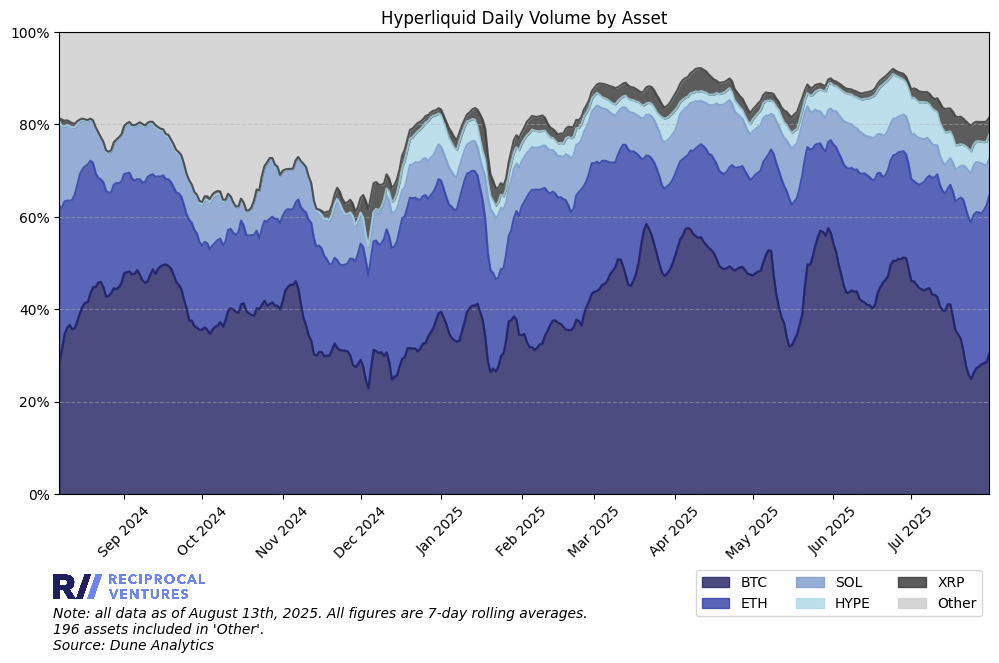

coin             BTC       ETH       SOL      HYPE       XRP     Other
date                                                                  
2025-07-27  0.275863  0.333853  0.108145  0.045473  0.042060  0.194606
2025-07-28  0.281042  0.325476  0.109132  0.046809  0.042781  0.194760
2025-07-29  0.283603  0.331839  0.097012  0.049242  0.043494  0.194809
2025-07-30  0.286253  0.339142  0.086817  0.051131  0.043350  0.193308
2025-07-31  0.304164  0.341521  0.079615  0.052813  0.036752  0.185134


In [14]:
start_date = '2024-08-01'
n_assets = 5
n_col = 3

hyperliquid_daily_voume_by_asset(start_date, n_assets, n_col)

In [15]:
# Function plot fees or revenue for any projects as a timeseries
def fees_or_revenue_timeseries(metric, assets, start_date, end_date):
    
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    
    metric_identifier = 'Revenue'
    if metric == 'dailyFees':
        metric_identifier = 'Fees'
    
    df_master = None

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for asset_slug, asset_name in assets.items():
        with open(f'raw-data/defillama-raw-data/{metric}_data/{asset_slug}_{metric_identifier}.json') as f:
            data = json.load(f)
        
        # Select only the two real keys, then rename
        raw_df = pd.DataFrame(
            data['totalDataChart'],
            columns=['date', asset_name]
        )
        raw_df.rename(columns={
            'date': 'timestamp',
            f'{metric}': asset_name
        }, inplace=True)
        raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
        raw_df = raw_df[['date', asset_name]]
        raw_df[asset_name] = raw_df[asset_name].rolling(window=7).mean()
    
        # Merge dataframes
        df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
        df_master.fillna(0).infer_objects(copy=False)

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
    
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]

    # Grab asset names
    assets = df_master.columns[1:].tolist()

    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[asset] for asset in assets]
    colors = asset_colors[:len(assets)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=assets,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}m'))
    delta = (end_date - pd.to_datetime(start_date)).days
    if delta <500:
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    elif delta < 60:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    else:
        ax.xaxis.set_major_locator(MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=45)
    ax.margins(x=0)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'Daily Fees by Protocol')
    if metric == 'dailyRevenue':
        ax.set_title(f'Daily Revenue by Protocol')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/breakout-{metric}-timeseries.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

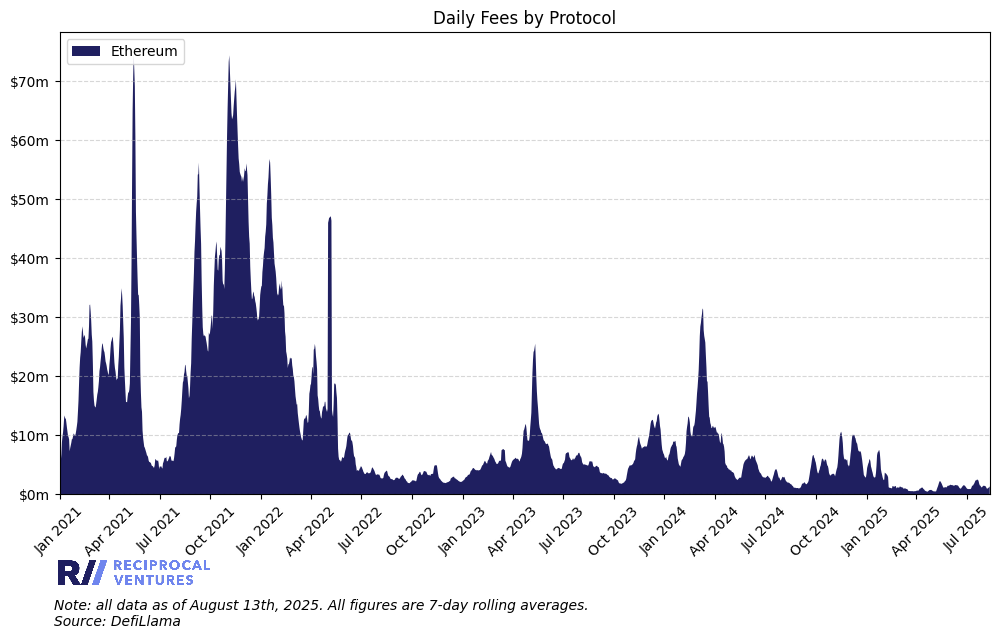

           date      Ethereum
3661 2025-08-08  9.172426e+05
3662 2025-08-09  1.002127e+06
3663 2025-08-10  1.074285e+06
3664 2025-08-11  1.160436e+06
3665 2025-08-12  1.302235e+06


In [16]:
# Call the function
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
start_date = '2021-01-01'
end_date = today
assets = {'ethereum': 'Ethereum'}

fees_or_revenue_timeseries(metric, assets, start_date, end_date)

In [17]:
def annualized_revenue_vs_price_to_annualized_metric(metric, asset_slug, asset_name, start_date, date):
    # Load revenue data
    with open(f'raw-data/defillama-raw-data/{metric[0]}_data/{asset_slug}_{metric[1]}.json', "r") as f:
        metric_data = json.load(f)
    
    metric_df = pd.DataFrame(metric_data["totalDataChart"], columns=["timestamp", f"{metric[1]}"])
    metric_df["date"] = pd.to_datetime(metric_df["timestamp"], unit="s")
    metric_df = metric_df[["date", f"{metric[1]}"]]
    
    # Annualize revenue and calculate trailing 7-day average
    metric_df[f'annualized-{metric[1]}'] = metric_df[f"{metric[1]}"] * 365
    metric_df[f"annualized-{metric[1]}-7d"] = metric_df[f"annualized-{metric[1]}"].rolling(window=7, min_periods=1).mean()

    # Load mcap data
    with open(f"raw-data/messari-raw-data/messari_{asset_id}_marketcap.json", 'r') as f:
        mcap_data = json.load(f)
    
    points = mcap_data['data']['points']
    mcap_df = pd.DataFrame(points, columns=[
        'timestamp',
        'circulating-marketcap',
        'circulating-marketcap-dominance',
        'fully-diluted-marketcap'
    ])
    mcap_df["date"] = pd.to_datetime(mcap_df["timestamp"], unit="s")
    mcap_df = mcap_df[['date','fully-diluted-marketcap']]
    mcap_df['FDV-7d'] = mcap_df['fully-diluted-marketcap'].rolling(window=7).mean()
    
    # Merge datasets
    df = pd.merge(metric_df, mcap_df, on="date", how="inner")
    
    # Calculate P/S ratio and trailing 7-day average
    df[f'FDV-to-annualized-{metric[1]}-multiple'] = df['fully-diluted-marketcap'] / df[f'annualized-{metric[1]}']
    df[f'FDV-to-annualized-{metric[1]}-multiple-7d'] = df[f'FDV-to-annualized-{metric[1]}-multiple'].rolling(window=7, min_periods=1).mean()

    # Filter the data for a given time period
    plot_df = df[df['date'] >= start_date]
    
    # 6) Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Area: Hyperliquid market share
    ax1.fill_between(
        plot_df["date"], plot_df[f"annualized-{metric[1]}-7d"],
        color="#a4a2a8", alpha=1,
        label=f"Annualized {metric[1]}"
    )
    ax1.set_ylabel(f"Annualized {metric[1]}")
    ax1.set_ylim(bottom=0)
    ax1.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'${x/1e9:,.0f}b'))
    
    # Monthly ticks, lighter crowding
    delta = (end_date - pd.to_datetime(start_date)).days
    if delta <500:
        ax1.xaxis.set_major_locator(MonthLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    elif delta < 60:
        ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    else:
        ax1.xaxis.set_major_locator(MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=45)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
    
    # Line: FDV / annualzied revenue
    ax2 = ax1.twinx()
    ax2.plot(
        plot_df["date"], plot_df[f"FDV-to-annualized-{metric[1]}-multiple-7d"],
        color="#1f1f60", linewidth=2,
        label=f"FDV / Annualized {metric[1]}"
    )
    ax2.set_ylabel(f"FDV / Annualized {metric[1]}")
    ax2.set_ylim(bottom=0)
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}x'))

    # no extra padding
    ax1.margins(x=0)
    
    # Title, grid & legend
    ax1.set_title(f"{asset_name}: Annualized {metric[1]} vs. FDV / Annualized {metric[1]}", fontsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")
    
    # Save & show
    add_logo(ax1, position=(0.075, -0.21))
    plt.figtext(0.065, -0.03, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari", ha='left', fontsize=10, style='italic')
    plt.tight_layout()
    plt.savefig(f"{plots_filepath}/{asset_id}-annualized-{metric[1]}_vs_FDV-to-annualized-{metric[1]}_7d.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Debug print
    print(df.tail(10))

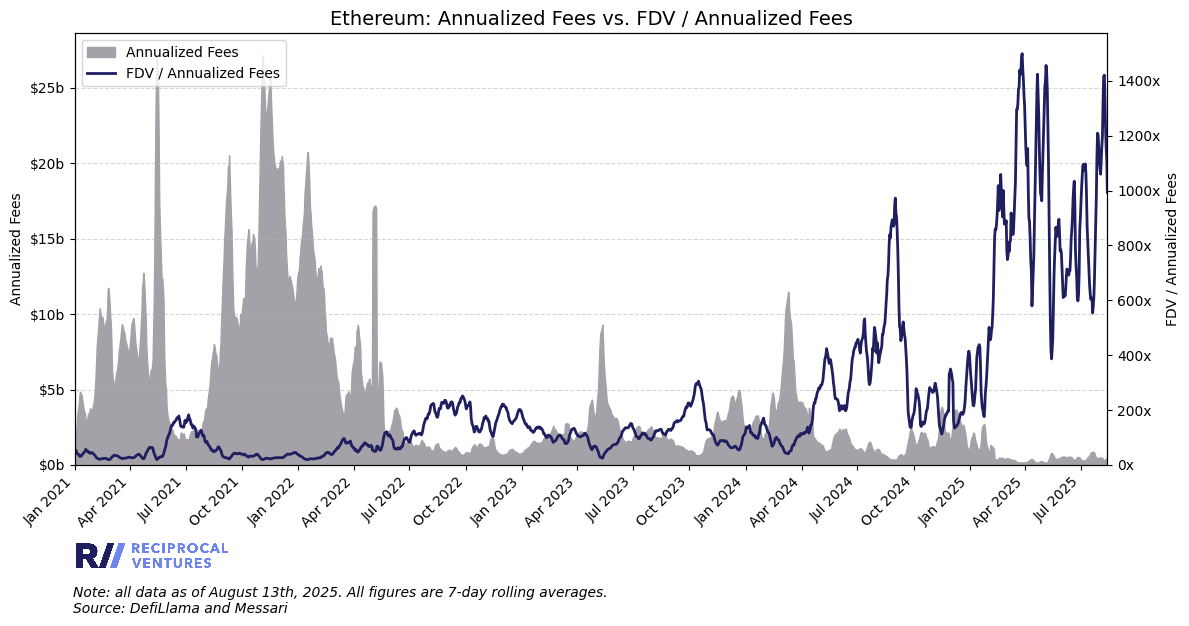

           date     Fees  annualized-Fees  annualized-Fees-7d  \
1676 2025-08-04   803874        293414010        4.862725e+08   
1677 2025-08-05  1196226        436622490        4.581733e+08   
1678 2025-08-06   857474        312978010        3.829608e+08   
1679 2025-08-07  1063935        388336275        3.287574e+08   
1680 2025-08-08  1259620        459761300        3.347935e+08   
1681 2025-08-09  1280770        467481050        3.657765e+08   
1682 2025-08-10  1058097        386205405        3.921141e+08   
1683 2025-08-11  1406932        513530180        4.235592e+08   
1684 2025-08-12  2188820        798919300        4.753159e+08   
1685 2025-08-13  2708784        988706160        5.718485e+08   

      fully-diluted-marketcap        FDV-7d  FDV-to-annualized-Fees-multiple  \
1676             4.491058e+11  4.380264e+11                      1530.621613   
1677             4.359695e+11  4.348636e+11                       998.504360   
1678             4.446982e+11  4.327008e+11 

In [18]:
metric = ('dailyFees', 'Fees')
assets = {'ethereum': 'Ethereum'}
start_date = '2021-01-01'

for asset_id, asset_name in assets.items():
    annualized_revenue_vs_price_to_annualized_metric(metric, asset_id, asset_name, start_date, date)

In [19]:
# Function for plotting revenue or fees / mcap or fdv charts for a set of assets

def revenue_vs_tvl_asset(start_date, assets, breakout_asset, bottom_metric, top_metric, category_title):
    df_master = None
    # Load revenue and FDV data
    for asset_slug, asset_name in assets.items():
        rev_path = f"raw-data/defillama-raw-data/daily{bottom_metric}_data/{asset_slug}_{bottom_metric}.json"
        with open(rev_path) as rev_f:
            rev_data = json.load(rev_f)
    
        rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{bottom_metric}"])
        rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
        rev_df[f"{asset_slug}-annualized-{bottom_metric}"] = rev_df[f"{asset_slug}-{bottom_metric}"] * 365
        rev_df = rev_df[["date", f"{asset_slug}-annualized-{bottom_metric}"]]

        # Load fdv data
        fdv_path = f'raw-data/messari-raw-data/messari_{asset_slug}_marketcap.json'
        with open(fdv_path) as fdv_f:
            fdv_data = json.load(fdv_f)
        
        points = fdv_data['data']['points']
        fdv_df = pd.DataFrame(points, columns=[
            'timestamp',
            'circulating-marketcap',
            'circulating-marketcap-dominance',
            'fully-diluted-marketcap'
        ])
        fdv_df["date"] = pd.to_datetime(fdv_df["timestamp"], unit="s")
        if top_metric == 'FDV':
            fdv_df = fdv_df[['date','fully-diluted-marketcap']]
            fdv_df.rename(columns={'fully-diluted-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)

        if top_metric == 'MCAP':
            fdv_df = fdv_df[['date','circulating-marketcap']]
            fdv_df.rename(columns={'circulating-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)
        
        # Merge datasets for a given asset
        interim_df = pd.merge(rev_df, fdv_df, on="date", how="inner")
        
        # Calculate multiple
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'] = interim_df[f'{asset_slug}-{top_metric}'] / interim_df[f'{asset_slug}-annualized-{bottom_metric}']
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'] = interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'].rolling(window=7).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    exclude = breakout_asset[0]
    
    # only include the others
    fdv_cols = [
        f"{slug}-{top_metric}"
        for slug in assets
        if slug != exclude
    ]
    mult_cols = [
        f"{slug}-{top_metric}-to-annualized-{bottom_metric}-multiple"
        for slug in assets
        if slug != exclude
    ]
    
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master[f'{top_metric}_weighted_avg_multiple'] = sum(weighted_terms)

    df_master[f'{top_metric}_weighted_avg_multiple-7d'] = df_master[f'{top_metric}_weighted_avg_multiple'].rolling(window=7).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: {top_metric} / Annualized {bottom_metric} (Log Scale)')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}x'))
    ax.set_ylim(1, 10000)

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari.",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{category_title} multiples.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    # Calculate statistical percentiles for multiple
    median_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].median(), 0)
    percentile_80_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80),0)
    percentile_20_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20),0)
    latest_cohort_multiple = round(df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1],0)
    median_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].median(), 0)
    percentile_80_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.80),0)
    percentile_20_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.20),0)
    latest_breakout_multiple = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].dropna().iloc[-1],0)

    stats_cohort = {
        "median_multiple": median_cohort,
        "80th_percentile_multiple": percentile_80_cohort,
        "20th_percentile_multiple": percentile_20_cohort,
        'latest_multiple': latest_cohort_multiple
    }

    stats_breakout = {
        "median_multiple": median_breakout,
        "80th_percentile_multiple": percentile_80_breakout,
        "20th_percentile_multiple": percentile_20_breakout,
        'latest_multiple': latest_breakout_multiple
    }
    
    # Print results in human-readable format
    print()
    print(f"{category_title} {top_metric} / Annualized {bottom_metric} Statistics (Excluding {breakout_asset[1]}):")
    print(f"Median {top_metric} / Annualized {bottom_metric}: {median_cohort:,.0f}x")
    print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_cohort:,.0f}x")
    print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_cohort:,.0f}x")
    print(f"Latest Multiple: {latest_cohort_multiple:,.0f}x")
    print()
    print(f"{breakout_asset[1]} {top_metric} / Annualized {bottom_metric} Statistics:")
    print(f"Median {top_metric} / Annualized {bottom_metric}: {median_breakout:,.0f}x")
    print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_breakout:,.0f}x")
    print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_breakout:,.0f}x")
    print(f"Latest Multiple: {latest_breakout_multiple:,.0f}x")
    print()

    return stats_cohort, stats_breakout

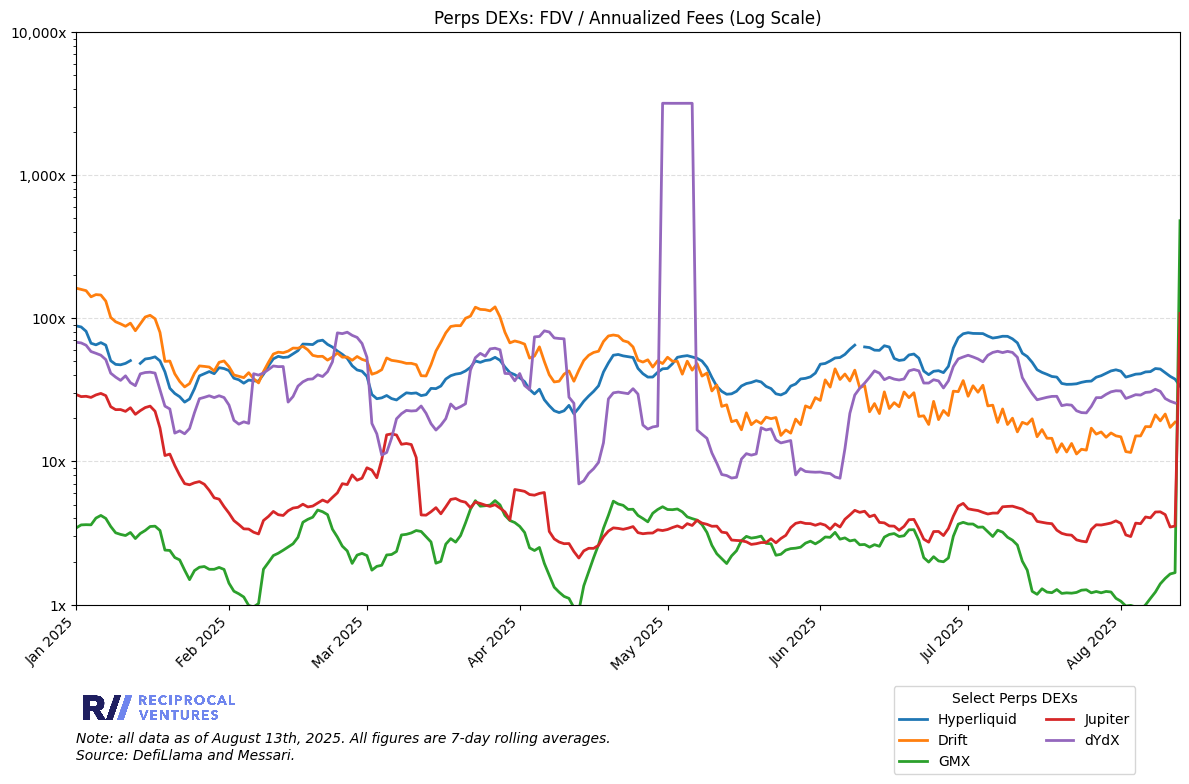


Perps DEXs FDV / Annualized Fees Statistics (Excluding Hyperliquid):
Median FDV / Annualized Fees: 10x
80th Percentile FDV / Annualized Fees: 16x
20th Percentile FDV / Annualized Fees: 6x
Latest Multiple: 7x

Hyperliquid FDV / Annualized Fees Statistics:
Median FDV / Annualized Fees: 40x
80th Percentile FDV / Annualized Fees: 60x
20th Percentile FDV / Annualized Fees: 27x
Latest Multiple: 23x



In [30]:
# Call the function for perp dexs
perps_dexs = {'hyperliquid': 'Hyperliquid',
          'drift': 'Drift',
          'gmx': 'GMX',
          'jupiter': 'Jupiter',
              'dydx': 'dYdX'
         }

# 'bottom_metric' should be 'Fees' or 'Revenue'; 'top_metric' should be 'FDV' or 'MCAP'
start_date = '2025-01-01'
assets = perps_dexs
breakout_asset = ('hyperliquid', 'Hyperliquid')
bottom_metric = 'Fees'
top_metric = 'FDV'
category_title = 'Perps DEXs'

perps_stats, breakout_stats = revenue_vs_tvl_asset(
    start_date     = start_date,
    assets         = perps_dexs,
    breakout_asset = breakout_asset,
    bottom_metric  = bottom_metric,
    top_metric     = top_metric,
    category_title = category_title
)

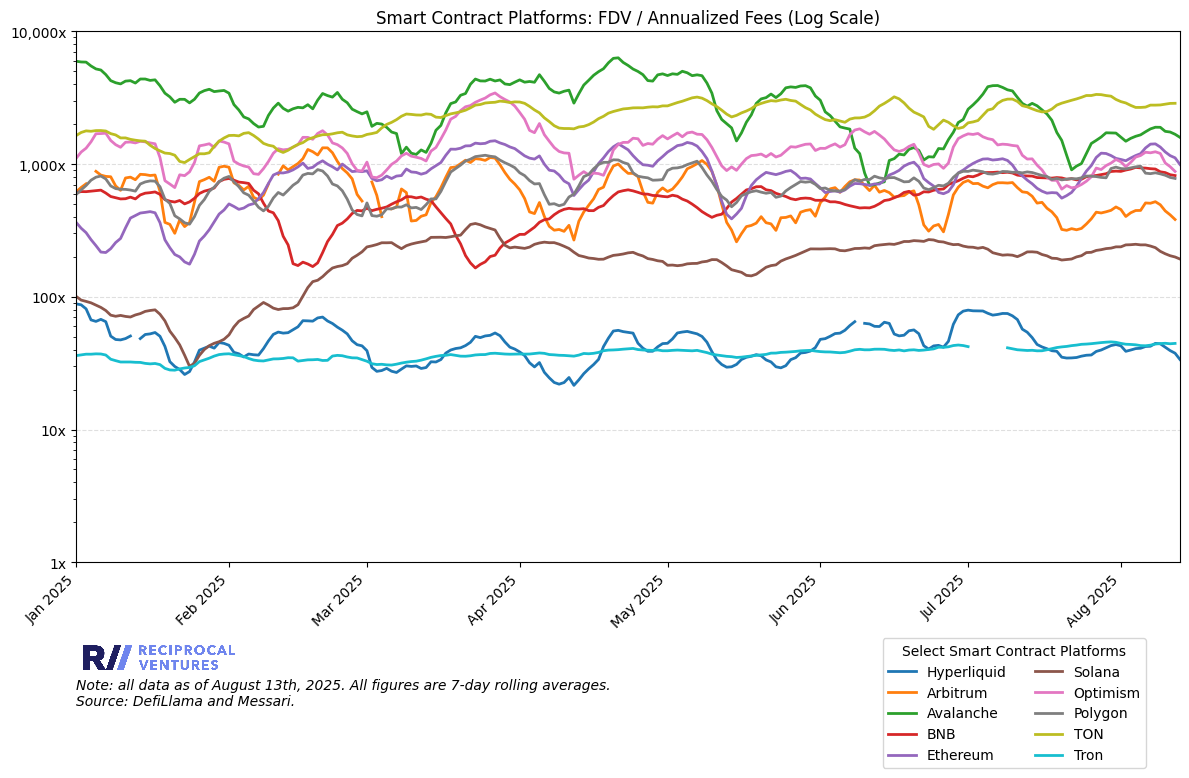


Smart Contract Platforms FDV / Annualized Fees Statistics (Excluding Hyperliquid):
Median FDV / Annualized Fees: 704x
80th Percentile FDV / Annualized Fees: 991x
20th Percentile FDV / Annualized Fees: 470x
Latest Multiple: 646x

Hyperliquid FDV / Annualized Fees Statistics:
Median FDV / Annualized Fees: 40x
80th Percentile FDV / Annualized Fees: 60x
20th Percentile FDV / Annualized Fees: 27x
Latest Multiple: 23x



In [31]:
# Call the function for smart contract platforms
smart_contract_platforms = {'hyperliquid': 'Hyperliquid',
          'arbitrum': 'Arbitrum',
          'avalanche': 'Avalanche',
          'bnb': 'BNB',
          'ethereum': 'Ethereum',
          'solana': 'Solana',
          'optimism': 'Optimism',
          'polygon': 'Polygon',
          'ton': 'TON',
          'tron': 'Tron'
             }

# 'bottom_metric' should be 'Fees' or 'Revenue'; 'top_metric' should be 'FDV' or 'MCAP'
assets = smart_contract_platforms
category_title = 'Smart Contract Platforms'

scp_stats, _ = revenue_vs_tvl_asset(
    start_date     = start_date,
    assets         = smart_contract_platforms,
    breakout_asset = breakout_asset,
    bottom_metric  = bottom_metric,
    top_metric     = top_metric,
    category_title = category_title
)

In [32]:
start_date = format_date_with_suffix(start_date)

combined_stats = pd.DataFrame({
    f'{breakout_asset[1]}':              breakout_stats,
    'Perps DEXs':                perps_stats,
    'Smart Contract Platforms': scp_stats

})

combined_stats.index = [
    'Median',
    '80th Percentile',
    '20th Percentile',
    'Most Recent'
]

styled = (
    combined_stats
      .style
      .set_caption(f"{top_metric} / Annualized {bottom_metric} Multiples by Cohort")
      .set_table_styles([
          {"selector": "caption",
           "props": [
             ("font-weight", "bold"),
             ("caption-side", "top"),
             ("text-decoration", "underline")
           ]},
          {"selector": "thead th", "props": [("font-weight", "normal")]},
          {"selector": "tbody th", "props": [("font-weight", "normal")]}
      ], overwrite=False)
      .format(lambda v: f"{v:,.0f}x" if pd.notnull(v) else "")
)

display(styled)


print(f"""
Notes:
 • All data from {start_date} to {date}.
 • Perp DEXs includes: Drift, dYdX, GMX, and Jupiter.
 • Smart Contract Platforms includes: Arbitrum, Avalanche,
   BNB, Ethereum, Solana, Optimism, Polygon, TON, and Tron.
 • Perps DEXs and Smart Contract Platforms multiples are
   daily FDV-weighted averages of all listed protocols.
 
 Sources: DefiLlama and Messari.
""")

,Hyperliquid,Perps DEXs,Smart Contract Platforms
Median,40x,10x,704x
80th Percentile,60x,16x,991x
20th Percentile,27x,6x,470x
Most Recent,23x,7x,646x



Notes:
 • All data from January 1st, 2025 to August 13th, 2025.
 • Perp DEXs includes: Drift, dYdX, GMX, and Jupiter.
 • Smart Contract Platforms includes: Arbitrum, Avalanche,
   BNB, Ethereum, Solana, Optimism, Polygon, TON, and Tron.
 • Perps DEXs and Smart Contract Platforms multiples are
   daily FDV-weighted averages of all listed protocols.
 
 Sources: DefiLlama and Messari.

